# Streaming Influence on Movie Trends

### Contributors: Sarah Kim, Nathaniel Kim, Terry Chen

Our project aims to observe how movie popularity trends have changed with the rise of major streaming platforms \(Netflix, Hulu, Amazon Prime, Disney\+\)\. Using the IMDb ratings and the Top rated movie dataset, along with an additional dataset containing streaming availability indicators for these major platforms, we will compare patterns in ratings, genre preferences, and box office revenue across the modern pre\-streaming era \(1990–2010\) and the current, streaming\-dominated era \(2010–present\)\. Including streaming availability data allows us to directly test how movies that are currently available on streaming platforms differ from movies released before streaming existed\.
Our primary hypothesis is that movies available on major streaming platforms today will cluster together in feature space, which would indicate that streaming\-available films share common traits like genre, runtime, ratings, or budget\. To explore this, we will use clustering methods \(K\-Means\) to identify natural groupings of movies and examine whether the streaming catalog exhibits distinct feature patterns\.
We will also use regression models to predict movie popularity from movie features, and conduct hypothesis testing to evaluate whether the introduction of streaming services has led to statistically significant changes in viewer behavior\. Key stakeholders include film studios, streaming platforms, distributors, and people working in marketing; these groups would find our project useful because they rely on predictions of audience interest to make decisions about investment and release strategy\. Additionally, ML is an ideal approach for this problem because the interaction between viewer preferences, trends, and movie success is a complex, nonlinear relationship that may be difficult to capture with simple analysis\. We will be using ML to observe trends and correlation/causation, and ultimately generate insights that help stakeholders understand how streaming has shaped the landscape of modern films\. 


### Question:

Are movies on streaming platforms today different in genre/runtime compared to movies released before streaming existed?

### Hypothesis:

Movies on major streaming platforms will cluster together in feature space, indicating that streaming\-available films share common traits \(genre, runtime, ratings, or budget\)\.

To explore these results, we will be using 1\. Unsupervised models to find natural groupings based on features, and 2\. Supervised models to test/validate the results from clustering\.

### Stakeholders:

Film studios, streaming platforms, distributors, and marketing teams

## 1\. Datasets and Cleaning

In this project, we will be using 3 datasets\-\-\-the IMDB dataset, Top rated movies dataset, and streaming dataset\.

Features Include:

IMDb: title, year, certificate, duration, genre, rating, description, stars, votes

Top rated: id, title, overview, release\_date, popularity, vote\_average, vote\_count

Streaming: ID, Title, Year, Age, Rotten Tomatoes, Netflix, Hulu, Prime video, Disney\+, Type

In [1]:
import pandas as pd
import re
import numpy as np

imdb_data = pd.read_csv('IMBD.csv')
movie_data = pd.read_csv('movie.csv')

In [2]:
print("IMBD.csv Data:")
imdb_data.head()

IMBD.csv Data:


,title,year,certificate,duration,genre,rating,description,stars,votes
0,Cobra Kai,(2018– ),TV-14,30 min,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"['Ralph Macchio, ', 'William Zabka, ', 'Courtn...","177,031"
1,The Crown,(2016– ),TV-MA,58 min,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...","199,885"
2,Better Call Saul,(2015–2022),TV-MA,46 min,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"['Bob Odenkirk, ', 'Rhea Seehorn, ', 'Jonathan...","501,384"
3,Devil in Ohio,(2022),TV-MA,356 min,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"['Emily Deschanel, ', 'Sam Jaeger, ', 'Gerardo...","9,773"
4,Cyberpunk: Edgerunners,(2022– ),TV-MA,24 min,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"['Zach Aguilar, ', 'Kenichiro Ohashi, ', 'Emi ...","15,413"


In [3]:
print("\nmovie.csv Data:")
movie_data.head()


movie.csv Data:


,Unnamed: 0,id,title,overview,release_date,popularity,vote_average,vote_count
0,0,960258,Shark Bait,A group of friends enjoying a weekend steal a ...,2022-05-13,34.679,5.697,318
1,1,11067,Major League II,"After losing in the ALCS the year before, the ...",1994-03-30,16.374,5.697,320
2,2,20856,Aliens in the Attic,A group of kids must protect their vacation ho...,2009-07-30,20.437,5.696,973
3,3,14098,100 Feet,After Marnie Watson kills her abusive husband ...,2008-07-22,18.927,5.696,304
4,4,11398,The Art of War,Neil Shaw is both agent and weapon - a critica...,2000-08-25,12.022,5.696,477


### 1a\. IMDB Dataset: Cleaning \(Nat\)

In [4]:
# Extracting the year from the year column. 
# This captures the first 4 numbers (we don't need end dates just start)
imdb_data["year_extracted"] = (
    imdb_data["year"]
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)
    .astype("Int64")
)

# Convert duration "30 min" -> 30; Easier to work with
imdb_data["duration_min"] = (
    imdb_data["duration"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype("float")
)

# Make votes numeric (remove commas); Easier to work with
imdb_data["votes_num"] = (
    imdb_data["votes"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype("float")
)

# One-hot encode genres: There are a lot so separating them into their own columns makes it easier to work with
imdb_data["genre"] = imdb_data["genre"].fillna("").astype(str).str.replace(r"[\[\]']", "", regex=True)
 #fillna with empty space so we don't accidentally OHE on null
imdb_data["genre_list"] = (imdb_data["genre"].str.split(",")
    .apply(lambda lst: [g.strip() for g in lst if g.strip() != ""])
)
genre_dummies = imdb_data["genre_list"].str.join("|").str.get_dummies()
imdb_data = pd.concat([imdb_data, genre_dummies], axis=1)

# Standardize title formatting (all lowercase)
imdb_data["title_clean"] = (
    imdb_data["title"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Display the cleaned data
print("\nCleaned IMBD.csv Data:")
imdb_data.head()


Cleaned IMBD.csv Data:


,title,year,certificate,duration,genre,rating,description,stars,votes,year_extracted,...,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western,title_clean
0,Cobra Kai,(2018– ),TV-14,30 min,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"['Ralph Macchio, ', 'William Zabka, ', 'Courtn...","177,031",2018,...,0,0,0,0,0,0,0,0,0,cobra kai
1,The Crown,(2016– ),TV-MA,58 min,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...","199,885",2016,...,0,0,0,0,0,0,0,0,0,the crown
2,Better Call Saul,(2015–2022),TV-MA,46 min,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"['Bob Odenkirk, ', 'Rhea Seehorn, ', 'Jonathan...","501,384",2015,...,0,0,0,0,0,0,0,0,0,better call saul
3,Devil in Ohio,(2022),TV-MA,356 min,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"['Emily Deschanel, ', 'Sam Jaeger, ', 'Gerardo...","9,773",2022,...,0,0,0,0,0,0,0,0,0,devil in ohio
4,Cyberpunk: Edgerunners,(2022– ),TV-MA,24 min,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"['Zach Aguilar, ', 'Kenichiro Ohashi, ', 'Emi ...","15,413",2022,...,0,0,0,0,0,0,0,0,0,cyberpunk: edgerunners


### 1b\. Movie Dataset: Cleaning \(Nat\)

In [5]:
# Drop the useless index column if present
if "Unnamed: 0" in movie_data.columns:
    movie_data = movie_data.drop(columns=["Unnamed: 0"])

# Convert release_date to datetime and get year; matches IMDB dataset
movie_data["release_date"] = pd.to_datetime(
    movie_data["release_date"], errors="coerce"
)
movie_data["year_movie"] = movie_data["release_date"].dt.year

# Standardize title formatting; Easier to work with (all lowercase)
movie_data["title_clean"] = (
    movie_data["title"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Display the cleaned data
print("\nCleaned Movie.csv Data:")
movie_data.head(20)


Cleaned Movie.csv Data:


,id,title,overview,release_date,popularity,vote_average,vote_count,year_movie,title_clean
0,960258,Shark Bait,A group of friends enjoying a weekend steal a ...,2022-05-13,34.679,5.697,318,2022,shark bait
1,11067,Major League II,"After losing in the ALCS the year before, the ...",1994-03-30,16.374,5.697,320,1994,major league ii
2,20856,Aliens in the Attic,A group of kids must protect their vacation ho...,2009-07-30,20.437,5.696,973,2009,aliens in the attic
3,14098,100 Feet,After Marnie Watson kills her abusive husband ...,2008-07-22,18.927,5.696,304,2008,100 feet
4,11398,The Art of War,Neil Shaw is both agent and weapon - a critica...,2000-08-25,12.022,5.696,477,2000,the art of war
5,11472,Nine Months,When he finds out his longtime girlfriend is p...,1995-07-12,17.622,5.695,631,1995,nine months
6,9562,Timeline,A group of archaeological students become trap...,2003-11-26,26.355,5.695,1041,2003,timeline
7,485811,Redcon-1,After a zombie apocalypse spreads from a Londo...,2018-09-07,21.648,5.693,303,2018,redcon-1
8,270774,Skiptrace,A detective from Hong Kong teams up with an Am...,2016-07-21,22.066,5.693,670,2016,skiptrace
9,480105,47 Meters Down: Uncaged,Four teenage girls go on a diving adventure to...,2019-08-15,22.417,5.692,1390,2019,47 meters down: uncaged


In [6]:
print("title_clean in movie_data?", "title_clean" in movie_data.columns)
print("title_clean in imdb_data?", "title_clean" in imdb_data.columns)

title_clean in movie_data? True
title_clean in imdb_data? True


### 1c\. IMDB and Top movies merged dataset:

This merged dataset shows the IMDB ratings, genre, etc\. for the top rated movies\. We merged these datasets because the IMDB dataset contains necessary information such as genre and duration for our project's hypothesis\.

In [7]:
# Columns from imdb_data that we want to bring into the merge
imdb_base_cols = [
    "title_clean",
    "rating",
    "votes_num",
    "duration_min",
    "year_extracted",
]

# All the one-hot genre columns (Action, Drama, Comedy, etc.)
genre_cols = genre_dummies.columns.tolist()

# Subset imdb_data to just what we need for the merge
imdb_for_merge = imdb_data[imdb_base_cols + genre_cols]

# Merge on title_clean
merged = pd.merge(
    movie_data,
    imdb_for_merge,
    on="title_clean",
    how="left",
    suffixes=("_movie", "_imdb"),
)

#Create binary post-2010 indicator (0 for pre-2010, 1 for post-2010)
merged["year_combined"] = merged["year_movie"].fillna(merged["year_extracted"])
merged["post_2010"] = (merged["year_combined"] > 2010).astype(int)
merged_df = merged[merged['rating'].notna()] #Dropping rows where IMDB doesn't have info for top movie

print("Merged data sample:")
merged_df.head(20)

Merged data sample:


,id,title,overview,release_date,popularity,vote_average,vote_count,year_movie,title_clean,rating,...,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western,year_combined,post_2010
8,270774,Skiptrace,A detective from Hong Kong teams up with an Am...,2016-07-21,22.066,5.693,670,2016,skiptrace,5.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2016,1
25,129,Spirited Away,"A young girl, Chihiro, becomes trapped in a st...",2001-07-20,139.663,8.535,16288,2001,spirited away,8.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2001,0
30,372058,Your Name.,High schoolers Mitsuha and Taki are complete s...,2016-08-26,102.811,8.488,11228,2016,your name.,8.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2016,1
32,122,The Lord of the Rings: The Return of the King,As armies mass for a final battle that will de...,2003-12-17,173.882,8.480,23876,2003,the lord of the rings: the return of the king,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2003,0
49,120,The Lord of the Rings: The Fellowship of the Ring,"Young hobbit Frodo Baggins, after inheriting a...",2001-12-18,186.299,8.414,24809,2001,the lord of the rings: the fellowship of the ring,8.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2001,0
50,120,The Lord of the Rings: The Fellowship of the Ring,"Young hobbit Frodo Baggins, after inheriting a...",2001-12-18,186.299,8.414,24809,2001,the lord of the rings: the fellowship of the ring,8.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2001,0
52,4935,Howl's Moving Castle,"Sophie, a young milliner, is turned into an el...",2004-09-09,95.447,8.403,9720,2004,howl's moving castle,8.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2004,0
57,121,The Lord of the Rings: The Two Towers,Frodo Baggins and the other members of the Fel...,2002-12-18,137.087,8.397,21558,2002,the lord of the rings: the two towers,8.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2002,0
70,568332,Taylor Swift: Reputation Stadium Tour,Taylor Swift takes the stage in Dallas for the...,2018-12-31,19.590,8.357,375,2018,taylor swift: reputation stadium tour,8.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2018,1
75,128,Princess Mononoke,"Ashitaka, a prince of the disappearing Emishi ...",1997-07-12,94.791,8.335,7871,1997,princess mononoke,8.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1997,0


### 1d\. Streaming Dataset: 

In [8]:
df_stream = pd.read_csv("MoviesOnStreamingPlatforms.csv")
stream_cols = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']
df_stream.head()

,Unnamed: 0,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,The Irishman,2019,18+,98/100,1,0,0,0,0
1,1,2,Dangal,2016,7+,97/100,1,0,0,0,0
2,2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0
3,3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0
4,4,5,Roma,2018,18+,94/100,1,0,0,0,0


In [9]:
#Drop unnecessary columns
if "Unnamed: 0" in df_stream.columns:
    df_stream = df_stream.drop(columns=["Unnamed: 0"])

#Standardize title
df_stream["title_clean"] = (
    df_stream["Title"]
    .astype(str)
    .str.lower()
    .str.strip()
)

#Clean the age column
# Keep original as a categorical string
df_stream["Age_raw"] = df_stream["Age"]
# Numeric minimum age (NaN where not numeric); i.e.) '18+ = 18'
df_stream["age_min"] = (
    df_stream["Age"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .where(df_stream["Age"].notna(), None)
)

#Cleaning Rotten Tomatoes score: from "98/100" -> 98
def parse_rt(value):
    if pd.isna(value):
        return None
    value = str(value)
    if "/" in value:           
        num, den = value.split("/", 1)
        try:
            num = float(num)
            den = float(den)
            # return num / den   # uncomment if you want 0–1
            return num          
        except ValueError:
            return None
    else:
        # If it's already a number, just return it (no '/')
        try:
            return float(value)
        except ValueError:
            return None

df_stream["rt_score"] = df_stream["Rotten Tomatoes"].apply(parse_rt)

#Identifying which platform the movie / show is available on
platform_cols = ["Netflix", "Hulu", "Prime Video", "Disney+"]

for col in platform_cols:
    df_stream[col] = df_stream[col].fillna(0).astype(int)


# Number of platforms where the title is available
df_stream["num_platforms"] = df_stream[platform_cols].sum(axis=1)

#Dropping all TV shows
df_stream = df_stream[df_stream['Type'] == 0]

# Display the cleaned data
print("\nCleaned Streaming Data.csv Data:")
df_stream.head()


Cleaned Streaming Data.csv Data:


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,title_clean,Age_raw,age_min,rt_score,num_platforms
0,1,The Irishman,2019,18+,98/100,1,0,0,0,0,the irishman,18+,18,98.0,1
1,2,Dangal,2016,7+,97/100,1,0,0,0,0,dangal,7+,7,97.0,1
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0,david attenborough: a life on our planet,7+,7,95.0,1
3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0,lagaan: once upon a time in india,7+,7,94.0,1
4,5,Roma,2018,18+,94/100,1,0,0,0,0,roma,18+,18,94.0,1


### 1e\. Merged all \(IMDB \+ Top Movies \+ Streaming\) 

Merging all three datasets to observe the differences across streaming vs\. non\-streaming movies\.

In [10]:
stream_features = df_stream[
    [
        "title_clean",
        "rt_score",
        "age_min",
        "num_platforms",
        "Netflix",
        "Hulu",
        "Prime Video",
        "Disney+",
    ]
].copy()

full_merged = pd.merge(
    merged_df,              
    stream_features,     
    on="title_clean",
    how="left",          
    suffixes=("", "_stream")
)

#Accounting for NaNs in from merge
stream_cols = ['Netflix','Hulu', 'Prime Video', 'Disney+', 'num_platforms']
full_merged[stream_cols] = full_merged[stream_cols].fillna(0)

#On streaming platform variable
full_merged['on_streaming'] = (full_merged['num_platforms'] > 0).astype(int) 

#Log transforming num_votes because skewed
full_merged['log_votes'] = np.log1p(full_merged['votes_num'])

print("\nColumns in final merged dataset:")
print(full_merged.columns.tolist())

print("\nFinal merged dataset sample:")
full_merged.head(7)


Columns in final merged dataset:
['id', 'title', 'overview', 'release_date', 'popularity', 'vote_average', 'vote_count', 'year_movie', 'title_clean', 'rating', 'votes_num', 'duration_min', 'year_extracted', 'Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Talk-Show', 'Thriller', 'War', 'Western', 'year_combined', 'post_2010', 'rt_score', 'age_min', 'num_platforms', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'on_streaming', 'log_votes']

Final merged dataset sample:


,id,title,overview,release_date,popularity,vote_average,vote_count,year_movie,title_clean,rating,...,post_2010,rt_score,age_min,num_platforms,Netflix,Hulu,Prime Video,Disney+,on_streaming,log_votes
0,270774,Skiptrace,A detective from Hong Kong teams up with an Am...,2016-07-21,22.066,5.693,670,2016,skiptrace,5.6,...,1,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,9.953610
1,129,Spirited Away,"A young girl, Chihiro, becomes trapped in a st...",2001-07-20,139.663,8.535,16288,2001,spirited away,8.6,...,0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,13.529402
2,372058,Your Name.,High schoolers Mitsuha and Taki are complete s...,2016-08-26,102.811,8.488,11228,2016,your name.,8.4,...,1,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,12.477446
3,122,The Lord of the Rings: The Return of the King,As armies mass for a final battle that will de...,2003-12-17,173.882,8.480,23876,2003,the lord of the rings: the return of the king,9.0,...,0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,14.413884
4,120,The Lord of the Rings: The Fellowship of the Ring,"Young hobbit Frodo Baggins, after inheriting a...",2001-12-18,186.299,8.414,24809,2001,the lord of the rings: the fellowship of the ring,8.8,...,0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,14.427478
5,120,The Lord of the Rings: The Fellowship of the Ring,"Young hobbit Frodo Baggins, after inheriting a...",2001-12-18,186.299,8.414,24809,2001,the lord of the rings: the fellowship of the ring,8.8,...,0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,14.427489
6,4935,Howl's Moving Castle,"Sophie, a young milliner, is turned into an el...",2004-09-09,95.447,8.403,9720,2004,howl's moving castle,8.2,...,0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,12.874617


## 2\. EDA 

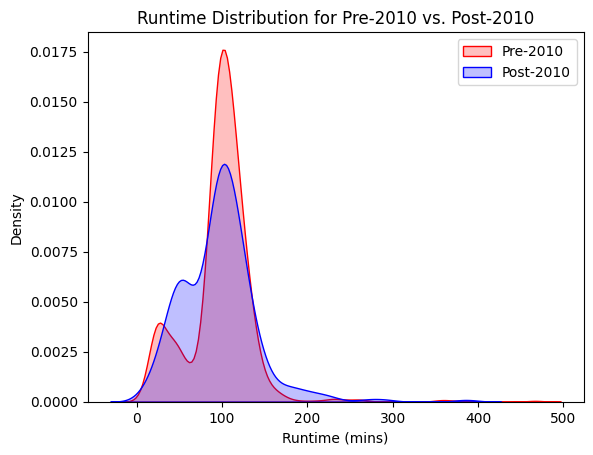

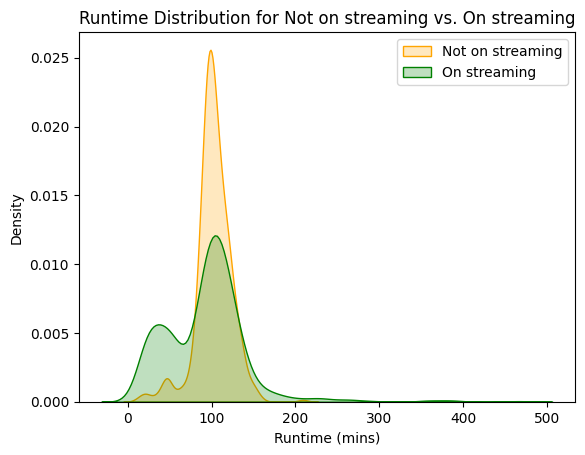

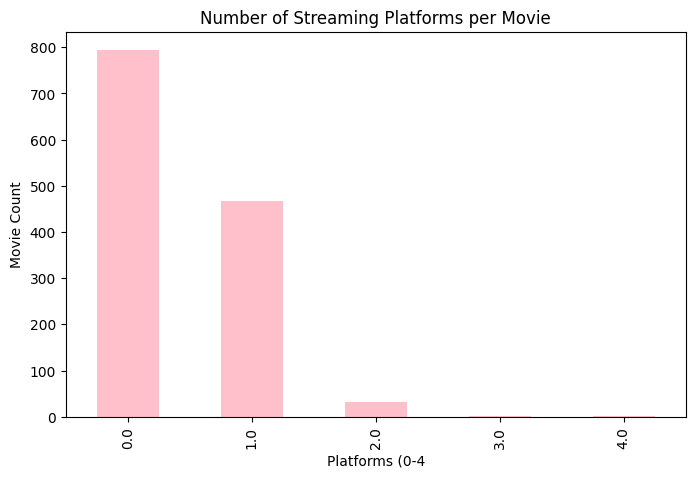

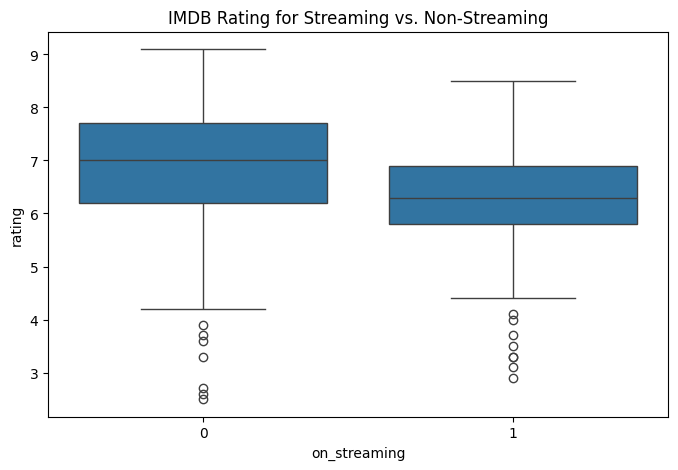

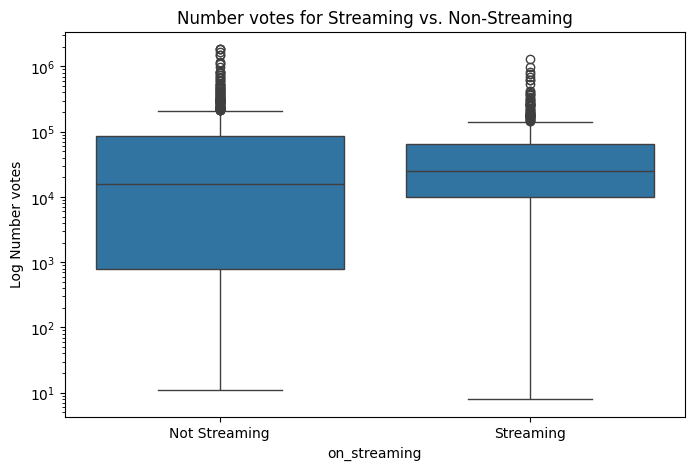

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

#Runtime distributions pre vs post
sns.kdeplot(data = full_merged, 
            x = 'duration_min', 
            hue = 'post_2010', 
            fill = True, 
            common_norm = False,
            palette = {0: 'blue', 1: 'red'})

plt.title('Runtime Distribution for Pre-2010 vs. Post-2010')
plt.xlabel('Runtime (mins)')
plt.ylabel('Density')
plt.legend(['Pre-2010', 'Post-2010'])
plt.show()

#Runtime distributions not on streaming, on streaming
#(showing that post-2010 and on-streaming features have similar distributions for other features)
sns.kdeplot(data = full_merged, 
            x = 'duration_min', 
            hue = 'on_streaming', 
            fill = True, 
            common_norm = False,
            palette = {0: 'green', 1: 'orange'})

plt.title('Runtime Distribution for Not on streaming vs. On streaming')
plt.xlabel('Runtime (mins)')
plt.ylabel('Density')
plt.legend(['Not on streaming', 'On streaming'])
plt.show()


#Genre counts (bar chart)
plt.figure(figsize = (8,5))
full_merged['num_platforms'].value_counts().sort_index().plot(
    kind = 'bar', 
    color = 'pink'
)
plt.title('Number of Streaming Platforms per Movie')
plt.xlabel('Platforms (0-4')
plt.ylabel('Movie Count')
plt.show()

#Streaming vs. non-streaming summary stats
#Rating
plt.figure(figsize = (8,5))
sns.boxplot(data = full_merged, x = 'on_streaming', y = 'rating')
plt.title('IMDB Rating for Streaming vs. Non-Streaming')
plt.show()

#Vote counts
plt.figure(figsize = (8,5))
sns.boxplot(data = full_merged, x = 'on_streaming', y = 'votes_num')
plt.yscale('log')
plt.xticks([0,1], ['Not Streaming', 'Streaming'])
plt.title('Number votes for Streaming vs. Non-Streaming')
plt.ylabel('Log Number votes')
plt.show()

## 3\. K\-Means Clustering

K\-Means Clustering on rating, duration, and log votes

In [12]:
# Fit K-Means
#Add cluster column to df
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_features = ['rating', 'duration_min', 'log_votes'] + genre_cols

# Feature matrix
X = full_merged[cluster_features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters = 3, random_state = 42)
full_merged['cluster'] = kmeans.fit_predict(X_scaled)

/root/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


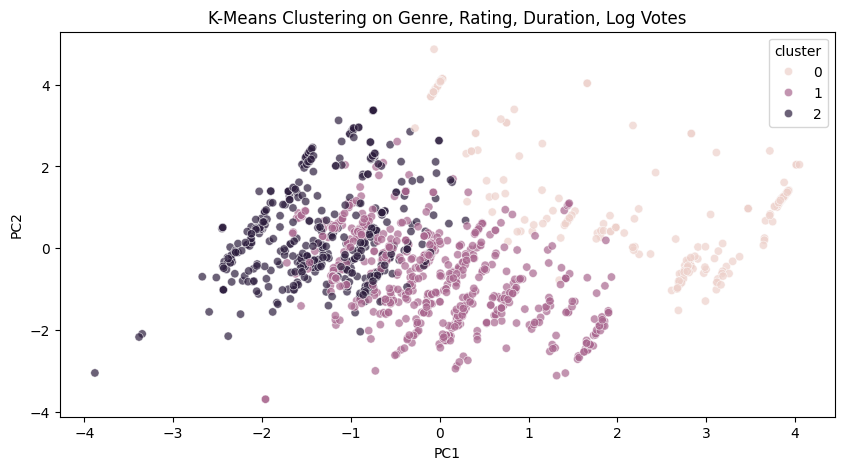

In [13]:
# Visualize clusters with PCA plot
pca = PCA(n_components = 2)
fitted_pca = pca.fit_transform(X_scaled)
full_merged['PC1'] = fitted_pca[:,0]
full_merged['PC2'] = fitted_pca[:, 1]

plt.figure(figsize = (10,5))
sns.scatterplot(data = full_merged, x = 'PC1', y = 'PC2', hue = 'cluster', alpha = 0.7)
plt.title('K-Means Clustering on Genre, Rating, Duration, Log Votes')
plt.show()

No distinct clusters\-\-\-suggests movie features lie along gradients rather than forming discrete categories\. Also, the lack of separation of clusters indicates that differences between pre and post\-streaming movie features are subtle\.

## 4\. Statistical tests: T\-test and Chi\-square

In [14]:
# T-test for runtime of streaming vs.non-streaming
# Is average runtime different pre vs. post-2010?
from scipy.stats import ttest_ind

pre_duration = full_merged[full_merged['post_2010'] == 0]['duration_min'].dropna()
post_duration = full_merged[full_merged['post_2010'] == 1]['duration_min'].dropna()
t, p1 = ttest_ind(pre_duration, post_duration, equal_var = False)
p1

0.7495850582305125

p1 < 0\.05, so we fail to reject null hypothesis; runtimes do not differ significantly between pre and post 2010 eras

In [15]:
# Chi-square for genre distribution of streaming vs. pre-streaming 
# Is the proportion of certain genres different pre vs. post-streaming era?
from scipy.stats import chi2_contingency

rare_genre = [genre for genre in genre_cols if full_merged[genre].sum() < 5]
full_merged['Other'] = full_merged[rare_genre].max(axis = 1)
main_genres = [g for g in genre_cols if g not in rare_genre] + ['Other']

genre_table = full_merged.groupby('post_2010')[main_genres].sum()
chi2, p2, dof, ex = chi2_contingency(genre_table)
p2

3.3098027797938024e-10

p2 < 0\.05, so genre proportions significantly changed after rise of streaming platforms

In [16]:
full_merged.head()

,id,title,overview,release_date,popularity,vote_average,vote_count,year_movie,title_clean,rating,...,Netflix,Hulu,Prime Video,Disney+,on_streaming,log_votes,cluster,PC1,PC2,Other
0,270774,Skiptrace,A detective from Hong Kong teams up with an Am...,2016-07-21,22.066,5.693,670,2016,skiptrace,5.6,...,0.0,0.0,0.0,0.0,0,9.953610,1,1.828893,-1.748728,0.0
1,129,Spirited Away,"A young girl, Chihiro, becomes trapped in a st...",2001-07-20,139.663,8.535,16288,2001,spirited away,8.6,...,0.0,0.0,0.0,0.0,0,13.529402,0,2.971882,-0.607939,0.0
2,372058,Your Name.,High schoolers Mitsuha and Taki are complete s...,2016-08-26,102.811,8.488,11228,2016,your name.,8.4,...,0.0,0.0,0.0,0.0,0,12.477446,0,0.590765,0.885392,0.0
3,122,The Lord of the Rings: The Return of the King,As armies mass for a final battle that will de...,2003-12-17,173.882,8.480,23876,2003,the lord of the rings: the return of the king,9.0,...,0.0,0.0,0.0,0.0,0,14.413884,1,0.421908,-2.018558,0.0
4,120,The Lord of the Rings: The Fellowship of the Ring,"Young hobbit Frodo Baggins, after inheriting a...",2001-12-18,186.299,8.414,24809,2001,the lord of the rings: the fellowship of the ring,8.8,...,0.0,0.0,0.0,0.0,0,14.427478,1,0.528164,-1.829119,0.0


## 5\. Logistic regression

In [17]:
full_merged['on_streaming']

0       0
1       0
2       0
3       0
4       0
       ..
1291    0
1292    0
1293    0
1294    1
1295    0
Name: on_streaming, Length: 1296, dtype: int64


Classification report:
              precision    recall  f1-score   support

           0      0.623     0.705     0.662       122
           1      0.673     0.587     0.627       126

    accuracy                          0.645       248
   macro avg      0.648     0.646     0.644       248
weighted avg      0.648     0.645     0.644       248


ROC-AUC: 0.6879065833983867


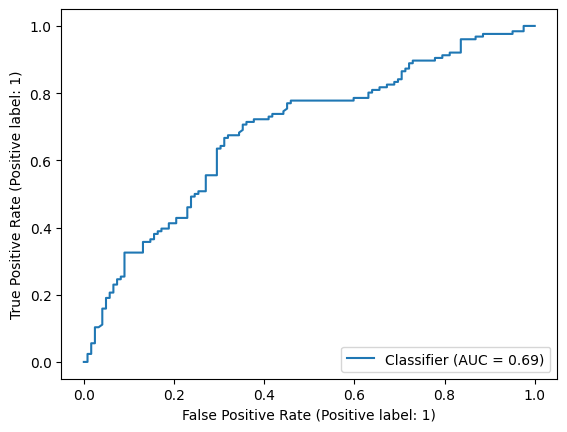

In [18]:
#Predicts popularity

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,RocCurveDisplay)

# 1. Create binary target variable based on median popularity
pop_thresh = full_merged['popularity'].median()
full_merged['popular'] = (full_merged['popularity'] >= pop_thresh).astype(int)

# 2. Define feature set
num_cols = ['duration_min', 'post_2010', 'on_streaming']

# genre dummy columns (from Action to Western)
all_cols = list(full_merged.columns)
start = all_cols.index('Action')
end = all_cols.index('Western')
genre_cols = all_cols[start:end+1]

feature_cols = num_cols + genre_cols

#Remove missing values
df_model = full_merged[feature_cols + ['popular']].dropna()

y5 = df_model['popular']
X5 = df_model[feature_cols]

# 3. Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X5, y5,
    test_size=0.2,
    random_state=42,
    stratify=y5
)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# 5. Fit model
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)
log_reg.fit(X_train_scaled, y_train)

# 6. Prediction + evaluation
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nROC-AUC:", roc_auc_score(y_test, y_proba))

RocCurveDisplay.from_predictions(y_test, y_proba)

In [19]:
import statsmodels.api as sm

X_sm_og = X_train_scaled[['duration_min', 'post_2010', 'on_streaming']].copy()
X_sm = sm.add_constant(X_sm_og)
model_sm = sm.Logit(y_train, X_sm).fit()

print(model_sm.summary())

ModuleNotFoundError: No module named 'statsmodels'